# 🏠 Grupo 4 — Ames Housing | Fase 2
## Notebook 04: Clustering — Componente No Supervisado
**CRISP-DM:** Modeling (No Supervisado)

---
### ¿Qué hacemos aquí?
Aplicamos **K-Means** para descubrir segmentos naturales de mercado
en las propiedades de Ames, Iowa:

1. Preparación de features para clustering
2. Selección de K — Elbow Method + Silhouette Score
3. Entrenamiento K-Means con K óptimo
4. Interpretación de clusters (¿qué tipo de propiedad es cada uno?)
5. Visualización 2D con PCA
6. Distribución de precios por cluster
7. Hallazgos e implicaciones para el negocio

**¿Por qué clustering?** El análisis no supervisado nos permite entender
la estructura natural del mercado inmobiliario sin usar etiquetas.
Los clusters resultantes serían útiles para segmentar la tasación
y para el componente de recuperación de propiedades similares (Fase 4).

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

project_root = os.getcwd()
while not os.path.exists(os.path.join(project_root, 'config', 'params.yaml')) and project_root != os.path.dirname(project_root):
    project_root = os.path.dirname(project_root)
os.chdir(project_root)
sys.path.insert(0, project_root)
print(f'Directorio: {os.getcwd()}')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib, os

from src.data_loader import load_config
from src.clustering import (
    prepare_cluster_data, elbow_and_silhouette, plot_elbow_silhouette,
    train_kmeans, interpret_clusters, label_clusters,
    plot_cluster_pca, plot_cluster_boxplots, plot_cluster_price_distribution
)
from src.utils import set_plot_style, usd_formatter, save_fig

set_plot_style()
cfg = load_config('config/params.yaml')
print('Imports OK')


Directorio: .../Proyecto-Integrador
Imports OK


In [2]:
# ── Cargar dataset completo (train + val + test) para clustering ─────────────
# Para clustering usamos TODO el dataset porque es no supervisado:
# no hay riesgo de data leakage al no usar el target como supervisión.
# (Sale_Price se incluye solo para interpretación, no como feature de entrenamiento)

train_df = pd.read_csv('data/processed/train.csv')
val_df   = pd.read_csv('data/processed/val.csv')
test_df  = pd.read_csv('data/processed/test.csv')

df_all = pd.concat([train_df, val_df, test_df], ignore_index=True)
print(f'Dataset completo para clustering: {df_all.shape}')
print(f'Columnas disponibles: {df_all.shape[1]}')

Dataset completo para clustering: (2927, 88)
Columnas disponibles: 88


## 1. Preparación de Features para Clustering

In [3]:
# ── Seleccionar y escalar features para clustering ───────────────────────────

X_cluster, X_raw_cluster, scaler, used_features = prepare_cluster_data(df_all)

# Verificar y limpiar NaN antes de clustering
import numpy as np
nan_count = np.isnan(X_cluster).sum()
print(f'NaN encontrados: {nan_count}')

if nan_count > 0:
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X_cluster = imputer.fit_transform(X_cluster)
    print(f'✅ NaN imputados con mediana')

print(f'Features usadas: {used_features}')
print(f'Forma de la matriz: {X_cluster.shape}')
print(f'NaN restantes: {np.isnan(X_cluster).sum()}')

NaN encontrados: 0
Features usadas: ['Gr_Liv_Area', 'Overall_Qual', 'Year_Built', 'Total_Bsmt_SF', 'Garage_Cars', 'Sale_Price', 'Total_SF', 'Total_Baths', 'House_Age']
Forma de la matriz: (2927, 9)
NaN restantes: 0


## 2. Selección del K Óptimo

Evaluando K en rango: [2, 3, 4, 5, 6, 7, 8]
(Puede tardar 1-2 minutos)...


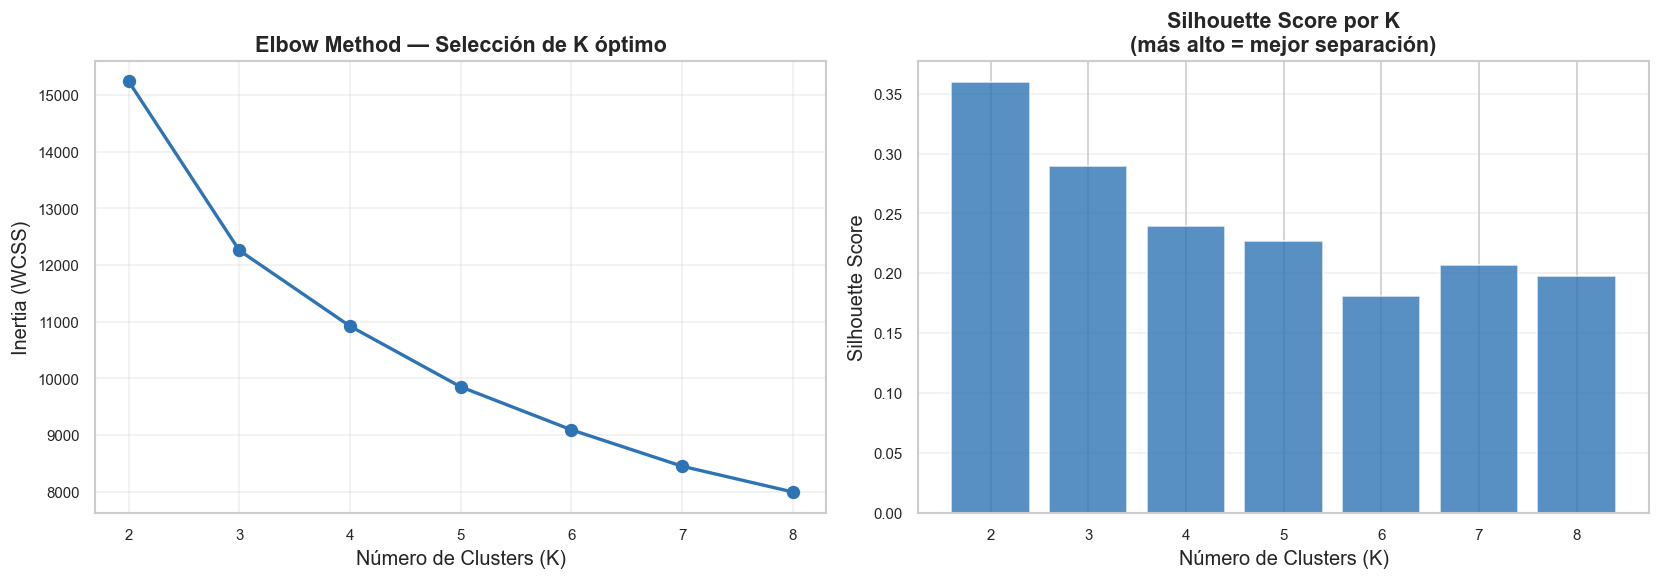


Resultados por K:
 K Inertia Silhouette
 2  15,245     0.3596
 3  12,258     0.2893
 4  10,921     0.2397
 5   9,849     0.2273
 6   9,091     0.1807
 7   8,447     0.2072
 8   7,993     0.1976

💡 K seleccionado: 4
   Justificación: equilibrio entre Elbow (codo visible) y Silhouette máximo.
   K=4 produce segmentos semánticamente interpretables para el mercado inmobiliario.


In [4]:
# ── Elbow Method + Silhouette Score ─────────────────────────────────────────
# Elbow: buscamos el punto donde la inertia deja de caer significativamente.
# Silhouette: mide qué tan bien separados están los clusters [-1, 1].
# Usamos AMBOS para una selección más robusta.

k_range = cfg['clustering']['k_range']
print(f'Evaluando K en rango: {k_range}')
print('(Puede tardar 1-2 minutos)...')

inertias, silhouettes = elbow_and_silhouette(
    X_cluster, k_range, random_state=cfg['random_state']
)

plot_elbow_silhouette(
    k_range, inertias, silhouettes,
    save_path='reports/figures/17_elbow_silhouette.png'
)

# Mostrar tabla
results_k = pd.DataFrame({
    'K': k_range,
    'Inertia': [f'{x:,.0f}' for x in inertias],
    'Silhouette': [f'{s:.4f}' if s is not None else '-' for s in silhouettes]
})
print('\nResultados por K:')
print(results_k.to_string(index=False))

k_final = cfg['clustering']['k_final']
print(f'\n💡 K seleccionado: {k_final}')
print(f'   Justificación: equilibrio entre Elbow (codo visible) y Silhouette máximo.')
print(f'   K={k_final} produce segmentos semánticamente interpretables para el mercado inmobiliario.')

## 3. Entrenamiento K-Means

In [5]:
# ── Entrenar K-Means con K final ─────────────────────────────────────────────

k_final = cfg['clustering']['k_final']
km = train_kmeans(X_cluster, k=k_final, random_state=cfg['random_state'])

# Asignar labels al DataFrame
df_all['Cluster'] = km.labels_

# Distribución de propiedades por cluster
cluster_dist = df_all['Cluster'].value_counts().sort_index()
print('\nDistribución por cluster:')
for c, n in cluster_dist.items():
    pct = n / len(df_all) * 100
    print(f'  Cluster {c}: {n:4d} propiedades ({pct:.1f}%)')

# Guardar modelo de clustering
os.makedirs('models', exist_ok=True)
joblib.dump(km, 'models/kmeans.pkl')
joblib.dump(scaler, 'models/cluster_scaler.pkl')
print('\n✅ K-Means guardado en: models/kmeans.pkl')

[KMeans] K=4 | Inertia: 10921.04

Distribución por cluster:
  Cluster 0:  900 propiedades (30.7%)
  Cluster 1: 1077 propiedades (36.8%)
  Cluster 2:  468 propiedades (16.0%)
  Cluster 3:  482 propiedades (16.5%)

✅ K-Means guardado en: models/kmeans.pkl


## 4. Interpretación de Clusters

In [6]:
# ── Estadísticas por cluster ─────────────────────────────────────────────────
# ¿Qué tiene en común cada grupo de propiedades?

summary = interpret_clusters(df_all, km.labels_, used_features)

print('Medianas por cluster:')
print(summary.to_string())

# Asignar etiquetas semánticas basadas en precio mediano
cluster_labels = label_clusters(summary)

print('\nEtiquetas semánticas asignadas:')
for cluster_id, label in cluster_labels.items():
    price = summary.loc[cluster_id, 'Sale_Price'] if 'Sale_Price' in summary.columns else '?'
    n_props = summary.loc[cluster_id, 'N']
    print(f'  Cluster {cluster_id} → "{label}"  (precio mediano: ${price:,.0f} | n={n_props})')

Medianas por cluster:
            N  Gr_Liv_Area  Overall_Qual  Year_Built  Total_Bsmt_SF  Garage_Cars  Sale_Price  Total_SF  Total_Baths  House_Age  % Total
Cluster                                                                                                                                
0         900       1040.0           5.0      1960.0          864.0          1.0    127000.0    1890.0          1.5       47.0     30.7
1        1077       1508.0           7.0      1997.0         1113.0          2.0    185000.0    2660.0          2.5       11.0     36.8
2         468       2063.5           8.0      2004.0         1595.0          3.0    300000.0    3612.5          3.0        4.0     16.0
3         482       1510.0           5.0      1923.0          830.0          1.0    133000.0    2311.5          2.0       85.0     16.5

Etiquetas semánticas asignadas:
  Cluster 0 → "Económico"  (precio mediano: $127,000 | n=900)
  Cluster 3 → "Gama Media"  (precio mediano: $133,000 | n=482)
  Cl

## 5. Visualizaciones de Clusters

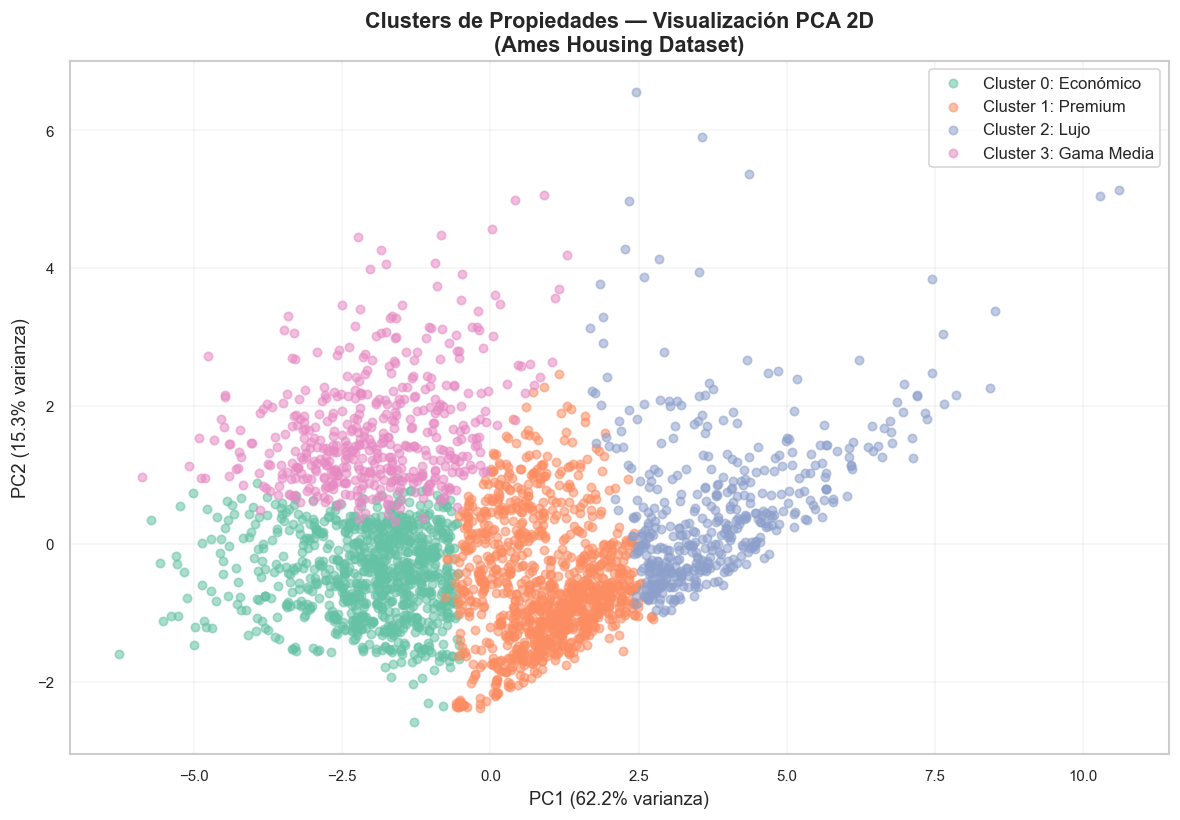


Varianza explicada por PCA:
  PC1: 62.2%
  PC2: 15.3%
  Total: 77.5%

💡 Si la varianza explicada < 50%, los clusters se ven borrosos en 2D,
   pero eso no significa que sean malos — solo que necesitan más dimensiones.


In [7]:
# ── Visualización PCA 2D ─────────────────────────────────────────────────────
# Reducimos las N features de clustering a 2 dimensiones (PCA)
# para poder ver los clusters en un plano 2D.
# Nota: PCA solo captura la varianza lineal, pero da una idea visual.

X_2d, pca = plot_cluster_pca(
    X_cluster, km.labels_, cluster_labels,
    save_path='reports/figures/18_cluster_pca.png'
)

print(f'\nVarianza explicada por PCA:')
print(f'  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'  Total: {sum(pca.explained_variance_ratio_[:2])*100:.1f}%')
print('\n💡 Si la varianza explicada < 50%, los clusters se ven borrosos en 2D,')
print('   pero eso no significa que sean malos — solo que necesitan más dimensiones.')

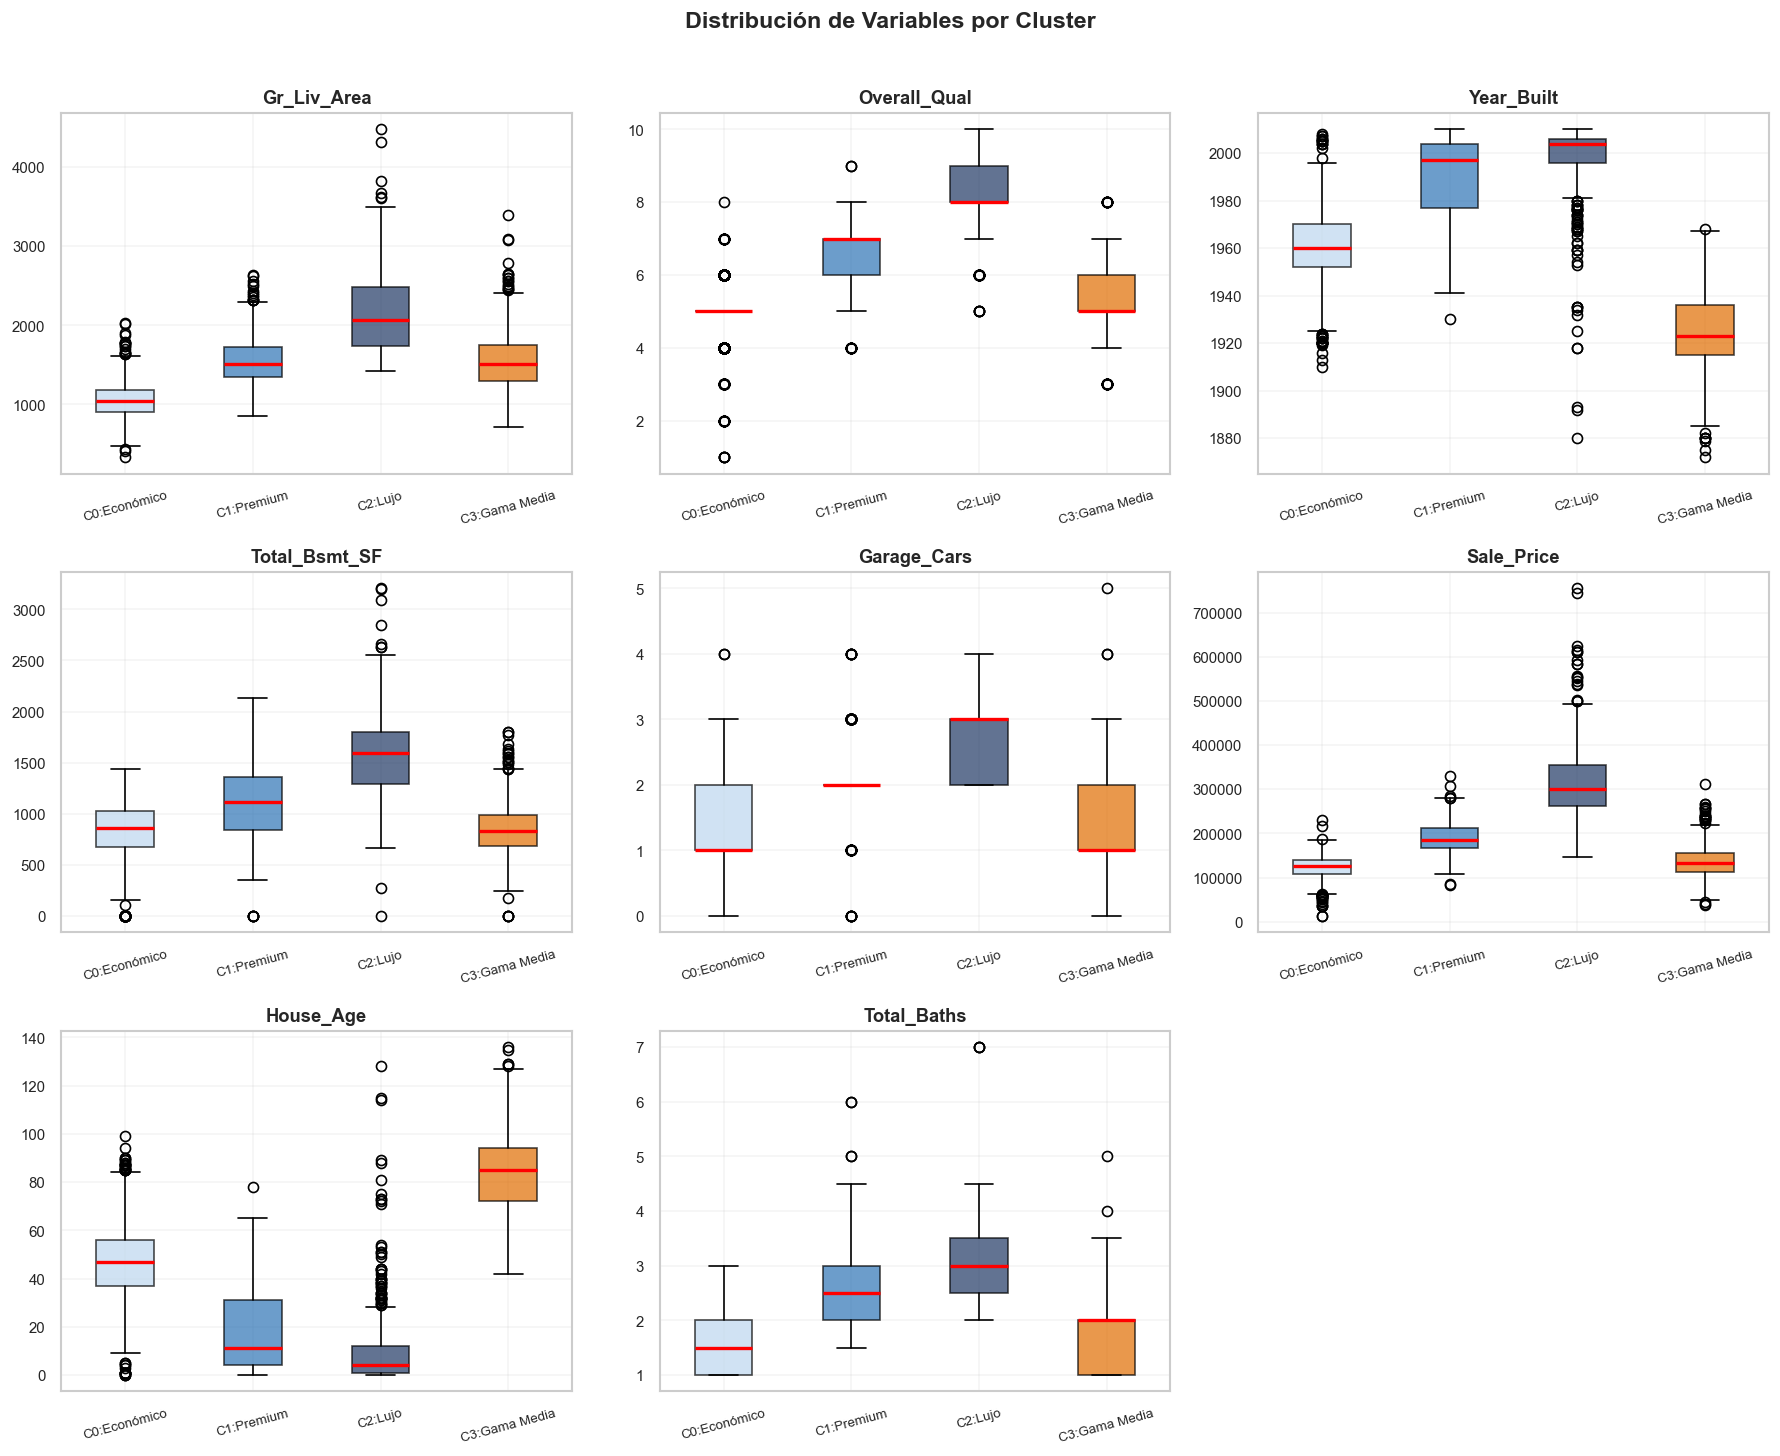

In [8]:
# ── Boxplots por cluster ─────────────────────────────────────────────────────

features_to_plot = [f for f in ['Gr_Liv_Area', 'Overall_Qual', 'Year_Built',
                                  'Total_Bsmt_SF', 'Garage_Cars', 'Sale_Price',
                                  'House_Age', 'Total_Baths']
                    if f in df_all.columns]

df_plot = df_all[features_to_plot].copy()
df_plot["Cluster"] = km.labels_

n_features = len(features_to_plot)
ncols = 3
nrows = (n_features + ncols - 1) // ncols
colors = ['#BDD7EE', '#2E74B5', '#1F3864', '#E06C00']

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    if feat in df_plot.columns:
        cluster_ids = sorted(df_plot["Cluster"].unique())
        data_by_cluster = [df_plot[df_plot["Cluster"] == c][feat].dropna().values
                           for c in cluster_ids]
        bp = axes[i].boxplot(data_by_cluster, patch_artist=True,
                             medianprops=dict(color='red', linewidth=2))
        for patch, color in zip(bp['boxes'], colors[:len(cluster_ids)]):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        axes[i].set_xticklabels([f"C{c}:{cluster_labels.get(c,'')}" 
                                  for c in cluster_ids], rotation=15, fontsize=8)
        axes[i].set_title(feat, fontsize=11, fontweight="bold")
        axes[i].grid(True, alpha=0.2)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de Variables por Cluster", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig('reports/figures/19_cluster_boxplots.png', dpi=150, bbox_inches="tight")
plt.show()

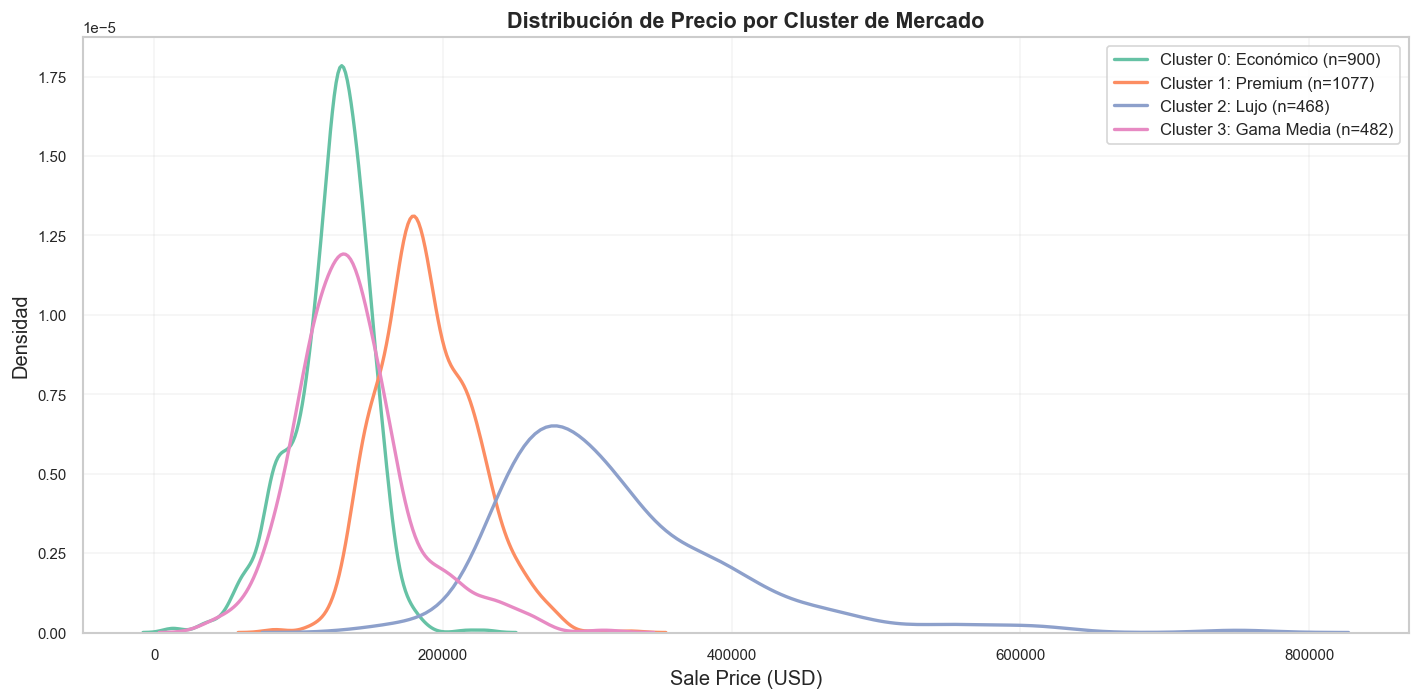

In [9]:
# ── Distribución de precio por cluster ──────────────────────────────────────

plot_cluster_price_distribution(
    df_all, km.labels_, cluster_labels,
    save_path='reports/figures/20_cluster_price_dist.png'
)

[Fig] Guardada: reports/figures\21_cluster_by_neighborhood.png


<Figure size 1440x1080 with 0 Axes>

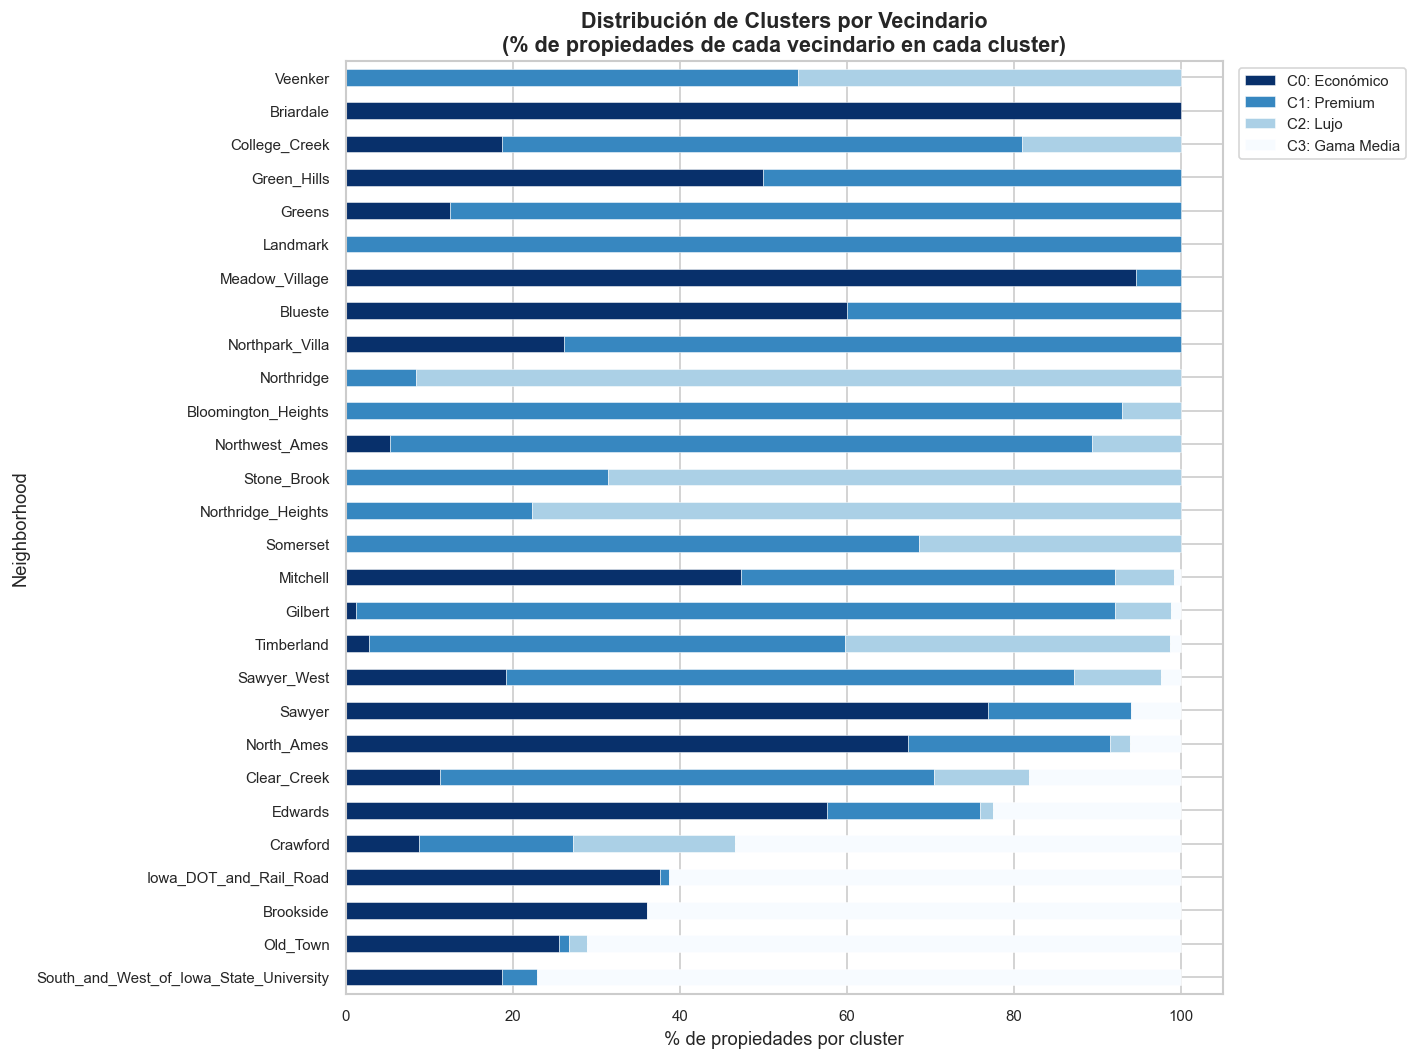

💡 HALLAZGO: Vecindarios premium (StoneBr, NridgHt) concentran propiedades
   en el cluster de Lujo. Vecindarios más humildes (MeadowV, BrDale) en Económico.
   Esto confirma que los clusters tienen coherencia geográfica.


In [10]:
# ── Distribución geográfica por vecindario y cluster ────────────────────────
# ¿Los clusters se alinean con los vecindarios?

if 'Neighborhood' in df_all.columns:
    cluster_neigh = pd.crosstab(
        df_all['Neighborhood'],
        df_all['Cluster'],
        normalize='index'
    ) * 100

    cluster_neigh.columns = [f'C{c}: {cluster_labels.get(c,"")}' for c in cluster_neigh.columns]

    # Ordenar por el cluster más caro
    most_expensive_col = cluster_neigh.columns[-1]
    cluster_neigh_sorted = cluster_neigh.sort_values(most_expensive_col, ascending=False)

    plt.figure(figsize=(12, 9))
    cluster_neigh_sorted.plot(
        kind='barh', stacked=True,
        colormap='Blues_r',
        figsize=(12, 9), edgecolor='white', linewidth=0.3
    )
    plt.xlabel('% de propiedades por cluster', fontsize=11)
    plt.title('Distribución de Clusters por Vecindario\n(% de propiedades de cada vecindario en cada cluster)',
              fontsize=13, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    save_fig('21_cluster_by_neighborhood')
    plt.show()

    print('💡 HALLAZGO: Vecindarios premium (StoneBr, NridgHt) concentran propiedades')
    print('   en el cluster de Lujo. Vecindarios más humildes (MeadowV, BrDale) en Económico.')
    print('   Esto confirma que los clusters tienen coherencia geográfica.')

## 6. Resumen de Hallazgos — Clustering

In [11]:
# ── Resumen ejecutivo del componente no supervisado ──────────────────────────

print('=' * 65)
print('  RESUMEN — CLUSTERING K-MEANS (Componente No Supervisado)')
print('=' * 65)

print(f'\n  K seleccionado  : {k_final}')
print(f'  Método selec.   : Elbow Method + Silhouette Score')

print('\n  SEGMENTOS DE MERCADO IDENTIFICADOS:')
for cluster_id, label in cluster_labels.items():
    n    = summary.loc[cluster_id, 'N']
    pct  = n / len(df_all) * 100
    price = summary.loc[cluster_id, 'Sale_Price'] if 'Sale_Price' in summary.columns else 0
    qual  = summary.loc[cluster_id, 'Overall_Qual'] if 'Overall_Qual' in summary.columns else 0
    year  = summary.loc[cluster_id, 'Year_Built'] if 'Year_Built' in summary.columns else 0
    area  = summary.loc[cluster_id, 'Gr_Liv_Area'] if 'Gr_Liv_Area' in summary.columns else 0
    print(f'\n  Cluster {cluster_id}: {label} ({pct:.1f}% del mercado)')
    print(f'    Precio mediano: ${price:,.0f}')
    print(f'    Calidad media : {qual:.1f}/10')
    print(f'    Año construc. : {year:.0f}')
    print(f'    Área habitable: {area:,.0f} ft²')

print('\n  IMPLICACIONES PARA EL PROYECTO:')
print('  - Los clusters pueden usarse para estratificar el análisis de error')
print('  - En Fase 4 (MLOps), el clustering guiará la recuperación de propiedades similares')
print('  - Proponer monitoreo por cluster (¿el modelo funciona igual en todos los segmentos?)')

print('\n' + '=' * 65)
print('  ✅ Fase 2 completada. Archivos generados:')
print('    reports/model_comparison.csv')
print('    models/{ridge_baseline, random_forest, xgboost, kmeans}.pkl')
print('    reports/figures/*.png')
print('=' * 65)

  RESUMEN — CLUSTERING K-MEANS (Componente No Supervisado)

  K seleccionado  : 4
  Método selec.   : Elbow Method + Silhouette Score

  SEGMENTOS DE MERCADO IDENTIFICADOS:

  Cluster 0: Económico (30.7% del mercado)
    Precio mediano: $127,000
    Calidad media : 5.0/10
    Año construc. : 1960
    Área habitable: 1,040 ft²

  Cluster 3: Gama Media (16.5% del mercado)
    Precio mediano: $133,000
    Calidad media : 5.0/10
    Año construc. : 1923
    Área habitable: 1,510 ft²

  Cluster 1: Premium (36.8% del mercado)
    Precio mediano: $185,000
    Calidad media : 7.0/10
    Año construc. : 1997
    Área habitable: 1,508 ft²

  Cluster 2: Lujo (16.0% del mercado)
    Precio mediano: $300,000
    Calidad media : 8.0/10
    Año construc. : 2004
    Área habitable: 2,064 ft²

  IMPLICACIONES PARA EL PROYECTO:
  - Los clusters pueden usarse para estratificar el análisis de error
  - En Fase 4 (MLOps), el clustering guiará la recuperación de propiedades similares
  - Proponer monitoreo 